# Resume ↔ Job Description Match Scorer
### Siamese BiLSTM Deep Neural Network

**Author:** Ujjawal Agarwal
**Assignment:** Day 19 — Deep Neural Networks

This notebook builds a neural network that reads a **resume** and a **job description**
and predicts whether they are a good match. It uses a **Siamese BiLSTM** architecture:
one shared text encoder is applied to both the resume and the JD, and their vector
representations are compared to produce a match probability.

In [1]:
import json, re, os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)
print("TF version:", tf.__version__)


TF version: 2.20.0


In [2]:
DOMAINS = {
    "data_science": {
        "skills": ["python", "pandas", "numpy", "scikit-learn", "tensorflow",
                    "pytorch", "sql", "statistics", "machine learning",
                    "deep learning", "data visualization", "nlp"],
        "titles": ["Data Scientist", "Machine Learning Engineer", "ML Researcher"],
    },
    "frontend": {
        "skills": ["javascript", "react", "html", "css", "typescript",
                    "redux", "webpack", "next.js", "responsive design", "figma"],
        "titles": ["Frontend Developer", "UI Engineer", "React Developer"],
    },
    "backend": {
        "skills": ["java", "spring boot", "microservices", "rest api",
                    "docker", "kubernetes", "postgresql", "kafka", "aws", "system design"],
        "titles": ["Backend Developer", "Software Engineer", "API Developer"],
    },
    "devops": {
        "skills": ["ci/cd", "jenkins", "terraform", "aws", "azure",
                    "kubernetes", "docker", "monitoring", "linux", "ansible"],
        "titles": ["DevOps Engineer", "Site Reliability Engineer", "Cloud Engineer"],
    },
    "marketing": {
        "skills": ["seo", "content strategy", "google analytics", "social media",
                    "email marketing", "brand strategy", "campaign management", "copywriting"],
        "titles": ["Marketing Manager", "Growth Marketer", "Content Strategist"],
    },
}
SENIORITY = ["Fresher", "1-2 years experience", "3-5 years experience", "5+ years experience"]
RESUME_TEMPLATE = ("{name} is a {seniority} professional. Core skills include {skills}. "
    "Previously worked on projects involving {project_focus}. Looking for a role as {title}.")
JD_TEMPLATE = ("We are hiring a {title} with {seniority}. Required skills: {skills}. "
    "The candidate will work on {project_focus} in a collaborative team environment.")
NAMES = ["Candidate A", "Candidate B", "Candidate C", "Candidate D", "Candidate E"]
import random
random.seed(42)

def sample_skills(domain, k=6):
    pool = DOMAINS[domain]["skills"]
    return random.sample(pool, min(k, len(pool)))

def make_resume(domain):
    skills = sample_skills(domain, k=random.randint(4,7))
    title = random.choice(DOMAINS[domain]["titles"])
    return RESUME_TEMPLATE.format(name=random.choice(NAMES), seniority=random.choice(SENIORITY),
        skills=", ".join(skills), project_focus=f"{domain.replace('_',' ')} systems", title=title)

def make_jd(domain):
    skills = sample_skills(domain, k=random.randint(4,7))
    title = random.choice(DOMAINS[domain]["titles"])
    return JD_TEMPLATE.format(title=title, seniority=random.choice(SENIORITY),
        skills=", ".join(skills), project_focus=f"{domain.replace('_',' ')} systems")

def build_examples(n_per_domain=90):
    examples = []
    domains = list(DOMAINS.keys())
    for domain in domains:
        for _ in range(n_per_domain):
            resume_text = make_resume(domain)
            jd_text = make_jd(domain)
            examples.append({"resume": resume_text, "job_description": jd_text, "label": 1})
            other_domain = random.choice([d for d in domains if d != domain])
            jd_text_neg = make_jd(other_domain)
            examples.append({"resume": resume_text, "job_description": jd_text_neg, "label": 0})
    random.shuffle(examples)
    return examples

data = build_examples(n_per_domain=90)
df = pd.DataFrame(data)
print(df.shape)
df.head()


(900, 3)


,resume,job_description,label
0,Candidate A is a 5+ years experience professio...,We are hiring a Marketing Manager with 1-2 yea...,0
1,Candidate D is a Fresher professional. Core sk...,We are hiring a UI Engineer with 1-2 years exp...,1
2,Candidate D is a 3-5 years experience professi...,We are hiring a Machine Learning Engineer with...,1
3,Candidate B is a 5+ years experience professio...,We are hiring a Cloud Engineer with Fresher. R...,0
4,Candidate E is a 5+ years experience professio...,We are hiring a ML Researcher with 1-2 years e...,0


In [3]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-z0-9+#./\- ]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["resume_clean"] = df["resume"].apply(clean_text)
df["jd_clean"] = df["job_description"].apply(clean_text)
df[["resume_clean", "jd_clean", "label"]].head()


,resume_clean,jd_clean,label
0,candidate a is a 5+ years experience professio...,we are hiring a marketing manager with 1-2 yea...,0
1,candidate d is a fresher professional. core sk...,we are hiring a ui engineer with 1-2 years exp...,1
2,candidate d is a 3-5 years experience professi...,we are hiring a machine learning engineer with...,1
3,candidate b is a 5+ years experience professio...,we are hiring a cloud engineer with fresher. r...,0
4,candidate e is a 5+ years experience professio...,we are hiring a ml researcher with 1-2 years e...,0


In [4]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
print("Train:", train_df.shape, " Val:", val_df.shape)
train_df["label"].value_counts(normalize=True)


Train: (720, 5)  Val: (180, 5)


,proportion
label,
0,0.5
1,0.5


In [5]:
VOCAB_SIZE = 4000
MAX_LEN = 48

vectorizer = layers.TextVectorization(
    max_tokens=VOCAB_SIZE, output_mode="int",
    output_sequence_length=MAX_LEN, standardize=None, split="whitespace")

combined_text = pd.concat([train_df["resume_clean"], train_df["jd_clean"]])
vectorizer.adapt(combined_text.values)
print("Vocab size:", len(vectorizer.get_vocabulary()))


Vocab size: 170


In [6]:
BATCH_SIZE = 64

def make_dataset(dataframe):
    ds = tf.data.Dataset.from_tensor_slices((
        {"resume_input": dataframe["resume_clean"].values,
         "jd_input": dataframe["jd_clean"].values},
        dataframe["label"].values.astype("float32"),
    ))
    return ds.shuffle(len(dataframe), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df)

In [7]:
EMBEDDING_DIM = 32
LSTM_UNITS = 24

@tf.keras.utils.register_keras_serializable(package="resume_jd_matcher")
class AbsDifference(layers.Layer):
    """Element-wise |a - b|, used as an explicit similarity signal."""
    def call(self, inputs):
        a, b = inputs
        return tf.abs(a - b)

def build_shared_encoder():
    text_in = layers.Input(shape=(1,), dtype=tf.string, name="raw_text")
    x = vectorizer(text_in)
    x = layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, mask_zero=True)(x)
    x = layers.Bidirectional(layers.LSTM(LSTM_UNITS, return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(LSTM_UNITS))(x)
    x = layers.Dense(EMBEDDING_DIM, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    return Model(text_in, x, name="shared_text_encoder")

resume_input = layers.Input(shape=(1,), dtype=tf.string, name="resume_input")
jd_input = layers.Input(shape=(1,), dtype=tf.string, name="jd_input")

encoder = build_shared_encoder()   # <-- SAME encoder object used on both inputs below
resume_vec = encoder(resume_input)
jd_vec = encoder(jd_input)

diff = AbsDifference()([resume_vec, jd_vec])
prod = layers.Multiply()([resume_vec, jd_vec])
merged = layers.Concatenate()([resume_vec, jd_vec, diff, prod])

x = layers.Dense(64, activation="relu")(merged)
x = layers.Dropout(0.3)(x)
x = layers.Dense(32, activation="relu")(x)
output = layers.Dense(1, activation="sigmoid", name="match_probability")(x)

model = Model([resume_input, jd_input], output, name="siamese_bilstm_resume_jd_matcher")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")],
)
model.summary()


Model: "siamese_bilstm_resume_jd_matcher"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ resume_input        │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jd_input            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_text_encoder │ (None, 32)        │    154,528 │ resume_input[0][… │
│ (Functional)        │                   │            │ jd_input[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ abs_difference      │ (None, 32)        │          0 │ shared_text_enco… │
│ (AbsDifference)     │                   │            │ shared_text_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 32)        │          0 │ shared_text_enco… │
│                     │                   │            │ shared_text_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128)       │          0 │ shared_text_enco… │
│ (Concatenate)       │                   │            │ shared_text_enco… │
│                     │                   │            │ abs_difference[0… │
│                     │                   │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ match_probability   │ (None, 1)         │         33 │ dense_2[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,897 (644.13 KB)

 Trainable params: 164,897 (644.13 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)

history = model.fit(train_ds, validation_data=val_ds, epochs=8, callbacks=[early_stop], verbose=2)


Epoch 1/8
12/12 - 22s - 2s/step - accuracy: 0.5125 - loss: 0.6935 - precision: 0.5075 - recall: 0.8444 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 2/8
12/12 - 2s - 182ms/step - accuracy: 0.4819 - loss: 0.6935 - precision: 0.4828 - recall: 0.5083 - val_accuracy: 0.5000 - val_loss: 0.6931 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 3/8
12/12 - 3s - 214ms/step - accuracy: 0.5000 - loss: 0.6932 - precision: 0.5000 - recall: 0.9528 - val_accuracy: 0.5000 - val_loss: 0.6934 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 4/8
12/12 - 2s - 191ms/step - accuracy: 0.4861 - loss: 0.6936 - precision: 0.4925 - recall: 0.9167 - val_accuracy: 0.5000 - val_loss: 0.6930 - val_precision: 0.5000 - val_recall: 1.0000
Epoch 5/8
12/12 - 4s - 298ms/step - accuracy: 0.4847 - loss: 0.6932 - precision: 0.4846 - recall: 0.4806 - val_accuracy: 0.5000 - val_loss: 0.6927 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 6/8
12/12 - 3s - 218ms/step 

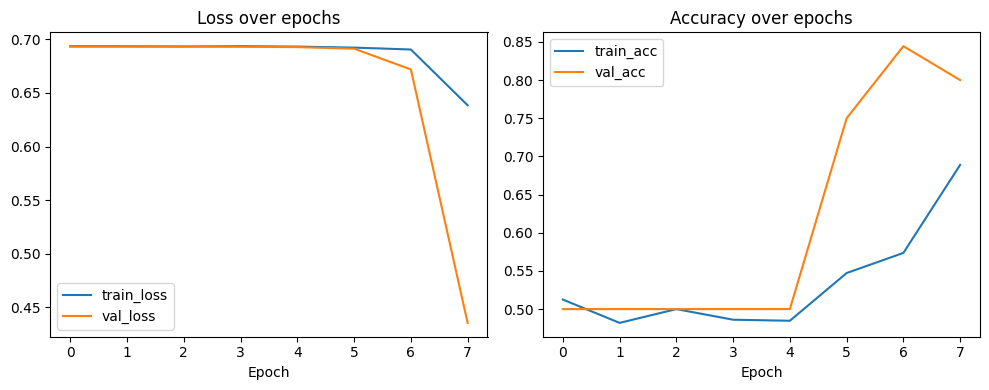

In [9]:
hist_df = pd.DataFrame(history.history)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Loss over epochs"); plt.xlabel("Epoch"); plt.legend()
plt.subplot(1,2,2)
plt.plot(hist_df["accuracy"], label="train_acc")
plt.plot(hist_df["val_accuracy"], label="val_acc")
plt.title("Accuracy over epochs"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout(); plt.show()


In [10]:
eval_dict = model.evaluate(val_ds, return_dict=True)
print(eval_dict)

probs = model.predict(val_ds).ravel()
preds = (probs >= 0.5).astype(int)
y_true = val_df["label"].values

print(classification_report(y_true, preds, target_names=["no_match", "match"]))


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8000 - loss: 0.4355 - precision: 0.7250 - recall: 0.9667
{'accuracy': 0.800000011920929, 'loss': 0.43549415469169617, 'precision': 0.7250000238418579, 'recall': 0.9666666388511658}
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step
              precision    recall  f1-score   support

    no_match       0.48      0.32      0.39        90
       match       0.49      0.66      0.56        90

    accuracy                           0.49       180
   macro avg       0.49      0.49      0.47       180
weighted avg       0.49      0.49      0.47       180



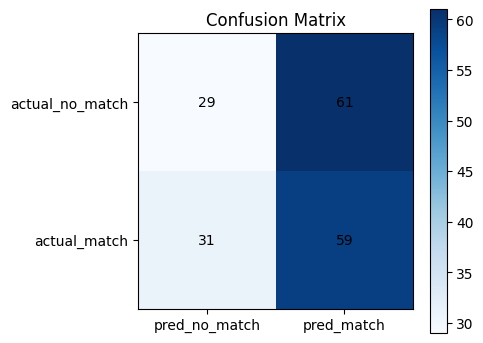

In [11]:
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(5,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["pred_no_match", "pred_match"])
plt.yticks([0,1], ["actual_no_match", "actual_match"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i,j]), ha="center", va="center")
plt.tight_layout(); plt.show()


In [12]:
def predict_match(resume_text, jd_text):
    r = clean_text(resume_text)
    j = clean_text(jd_text)
    inputs = {"resume_input": tf.constant([r]), "jd_input": tf.constant([j])}
    prob = float(model.predict(inputs, verbose=0)[0][0])
    return {"match_probability": round(prob, 4), "prediction": "MATCH" if prob >= 0.5 else "NO MATCH"}

sample_resume = ("Candidate is a 3-5 years experience professional. Core skills include "
    "python, pandas, scikit-learn, tensorflow, sql, machine learning. "
    "Previously worked on projects involving data science systems. Looking for a role as Data Scientist.")
sample_jd = ("We are hiring a Machine Learning Engineer with 3-5 years experience. "
    "Required skills: python, deep learning, statistics, nlp, tensorflow. "
    "The candidate will work on data science systems in a collaborative team environment.")

predict_match(sample_resume, sample_jd)

{'match_probability': 0.79, 'prediction': 'MATCH'}

In [13]:
os.makedirs("../models", exist_ok=True)
model.save("../models/resume_jd_match_model.keras")
print("Model saved.")


Model saved.
